<a href="https://colab.research.google.com/github/aniq63/Airbnb-NYC-DataAnalytics/blob/main/notebooks/Airbnb_NYC_Data_Analytics_Data_Obatin_and_Scrubing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OBTAIN AND SCRUB THE DATA

## OBTAINING THE DATA

In [37]:
import pandas as pd
import numpy as np

In [38]:
df = pd.read_csv('/content/Airbnb_Open_Data.csv', low_memory = False)

In [39]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


## SCRUBING THE DATA

In [40]:
df.shape

(102599, 26)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [42]:
# Droping the unuseful columns

dropped_columns = [
    "license",
    "house_rules",
    "last review",
    "country",
    "country code",
    "host name",
    "host id",
    "NAME",
    "id",
    "neighbourhood"
]

df.drop(columns=dropped_columns, inplace=True)

In [43]:
df.shape

(102599, 16)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   host_identity_verified          102310 non-null  object 
 1   neighbourhood group             102570 non-null  object 
 2   lat                             102591 non-null  float64
 3   long                            102591 non-null  float64
 4   instant_bookable                102494 non-null  object 
 5   cancellation_policy             102523 non-null  object 
 6   room type                       102599 non-null  object 
 7   Construction year               102385 non-null  float64
 8   price                           102352 non-null  object 
 9   service fee                     102326 non-null  object 
 10  minimum nights                  102190 non-null  float64
 11  number of reviews               102416 non-null  float64
 12  reviews per mont

### Data Type Correction

In [45]:
## Correct data type

# Remove the dollar sign from the price and service fee columns
currency_cols = ['price', 'service fee']
for col in currency_cols:
    # 1. Remove the dollar sign and commas (and any potential whitespace)
    df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()


df = df.astype({
    'price': float,
    'service fee' : float,
    'Construction year' : pd.Int64Dtype(),
    'minimum nights' : pd.Int64Dtype(),
    'number of reviews' : pd.Int64Dtype(),
    'calculated host listings count' : pd.Int64Dtype(),
    'availability 365' : pd.Int64Dtype()

})

### Remove & Fill the Null values

In [46]:
df.isnull().sum()

,0
host_identity_verified,289
neighbourhood group,29
lat,8
long,8
instant_bookable,105
cancellation_policy,76
room type,0
Construction year,214
price,247
service fee,273


In [47]:
df['reviews per month'].unique()

array([ 0.21,  0.38,   nan, ...,  7.73, 24.49, 33.08])

In [48]:
df['reviews per month'].mean()

np.float64(1.374021909594096)

In [49]:
df['reviews per month'].median()

0.74

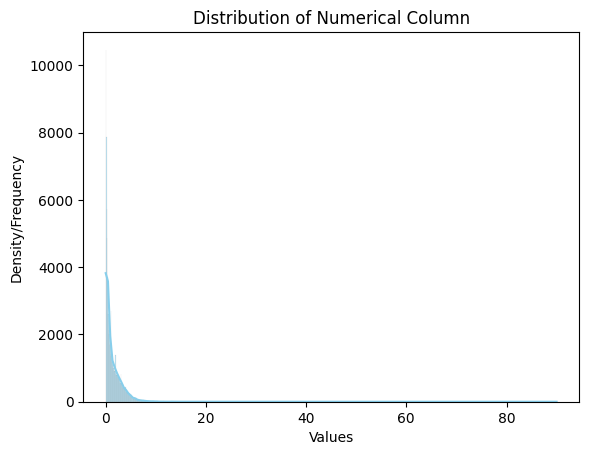

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['reviews per month'], kde=True, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Values')
plt.ylabel('Density/Frequency')
plt.title('Distribution of Numerical Column')

# Display the plot
plt.show()

In [51]:
median_value = df['reviews per month'].median()
df['reviews per month'].fillna(median_value, inplace=True)

/tmp/ipykernel_2984/1377438740.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews per month'].fillna(median_value, inplace=True)


In [52]:
df.isnull().sum()

,0
host_identity_verified,289
neighbourhood group,29
lat,8
long,8
instant_bookable,105
cancellation_policy,76
room type,0
Construction year,214
price,247
service fee,273


In [53]:
df.dropna(inplace = True)

In [54]:
df.isnull().sum()

,0
host_identity_verified,0
neighbourhood group,0
lat,0
long,0
instant_bookable,0
cancellation_policy,0
room type,0
Construction year,0
price,0
service fee,0


In [55]:
df.shape

(100109, 16)

### Duplicates in Data

In [56]:
df.duplicated().sum()

np.int64(3598)

In [57]:
df.drop_duplicates(inplace=True)

### Analyzing the Data inside Columns

In [58]:
for x in df.select_dtypes(include='object'):
  print("Column Name:", x)
  print("Number of Categories:")
  print(df[x].nunique())
  print("Categories:")
  print(df[x].unique())
  print("-"*30)

Column Name: host_identity_verified
Number of Categories:
2
Categories:
['unconfirmed' 'verified']
------------------------------
Column Name: neighbourhood group
Number of Categories:
6
Categories:
['Brooklyn' 'Manhattan' 'brookln' 'Queens' 'Bronx' 'Staten Island']
------------------------------
Column Name: instant_bookable
Number of Categories:
2
Categories:
[False True]
------------------------------
Column Name: cancellation_policy
Number of Categories:
3
Categories:
['strict' 'moderate' 'flexible']
------------------------------
Column Name: room type
Number of Categories:
4
Categories:
['Private room' 'Entire home/apt' 'Shared room' 'Hotel room']
------------------------------


### Checking an Outlier
Especially that don't make any kind of sense like price is -50 $

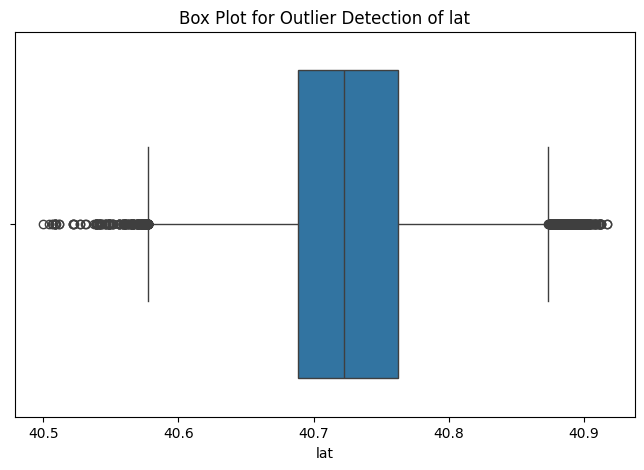

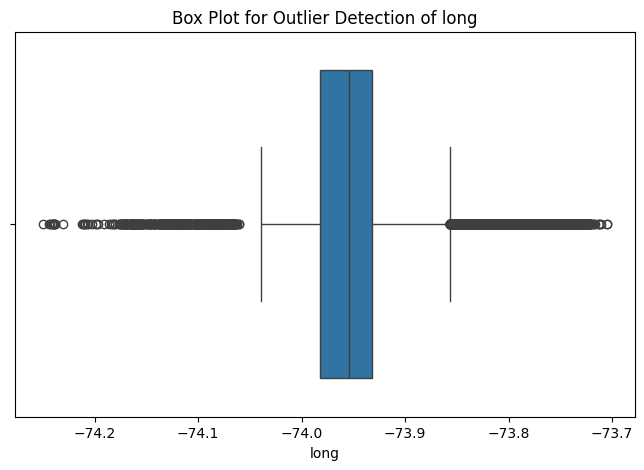

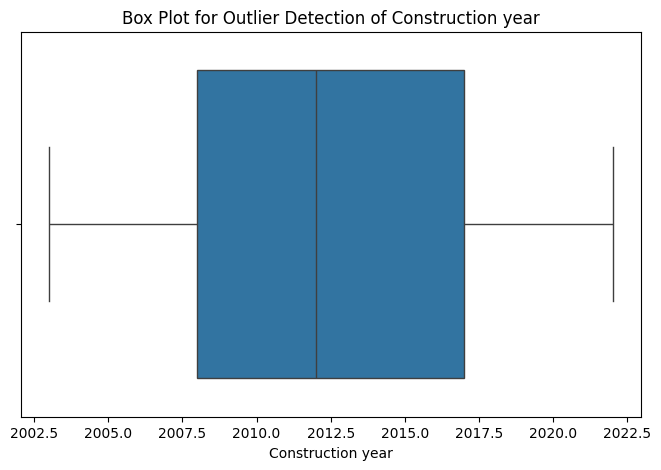

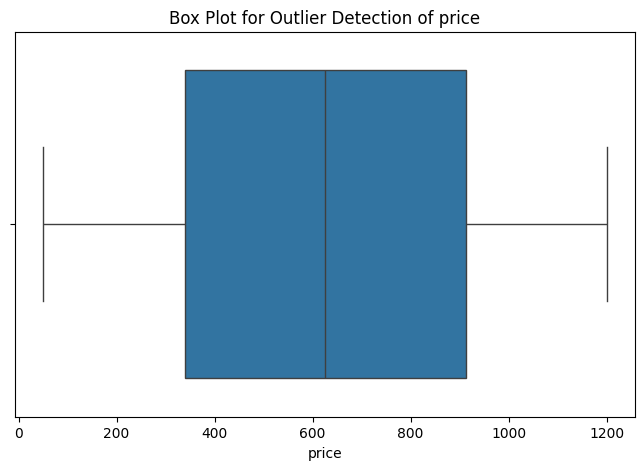

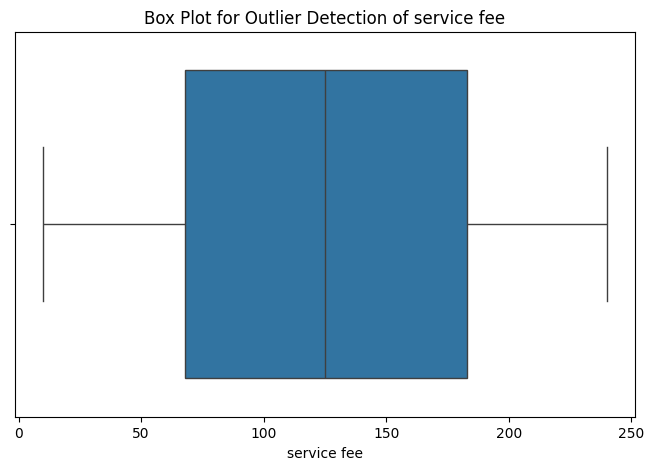

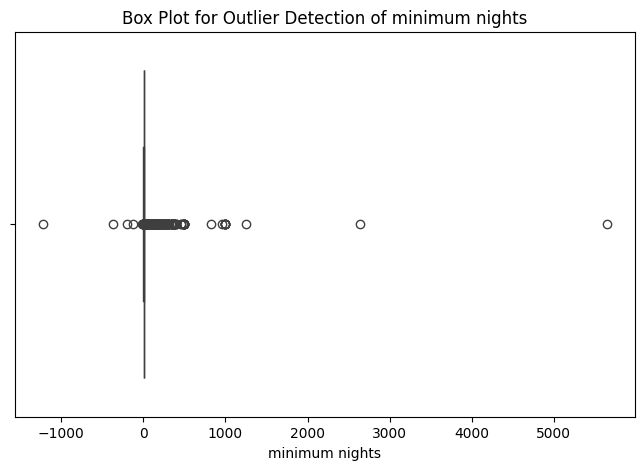

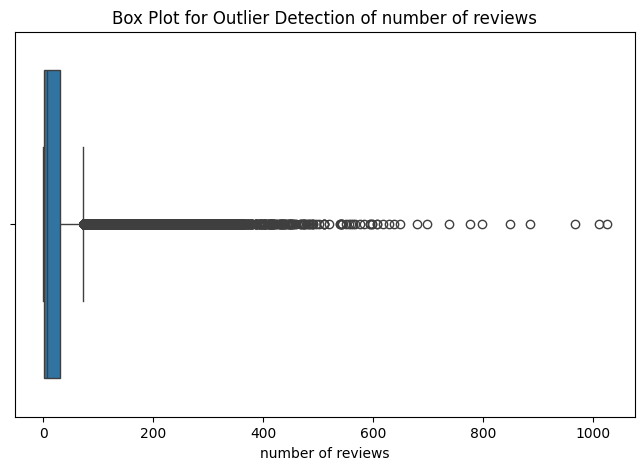

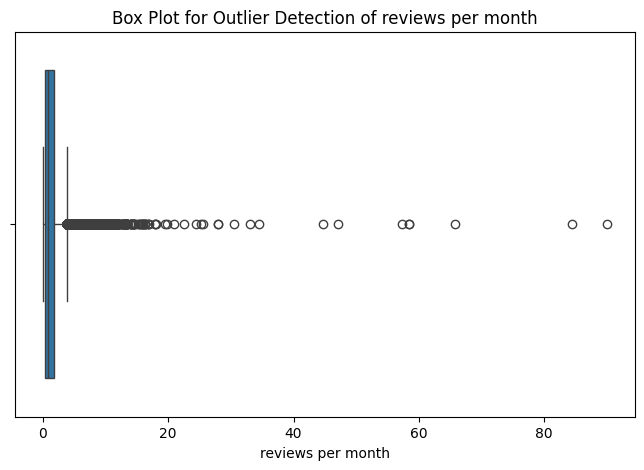

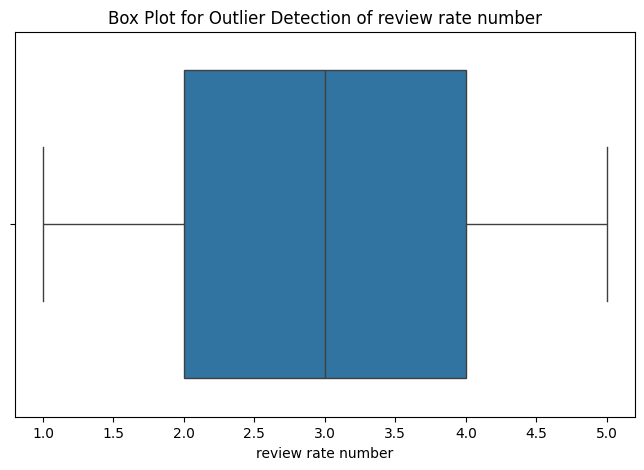

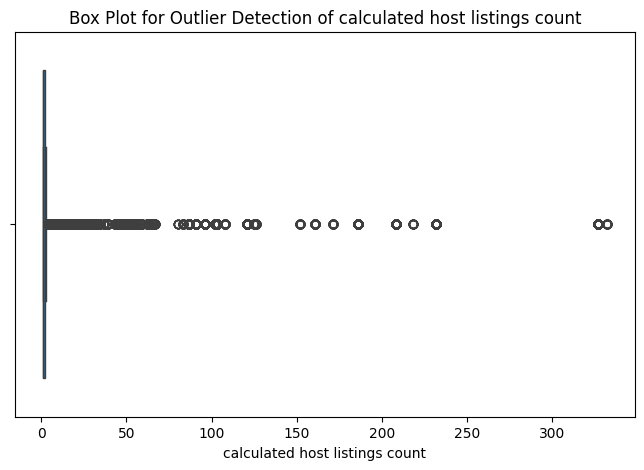

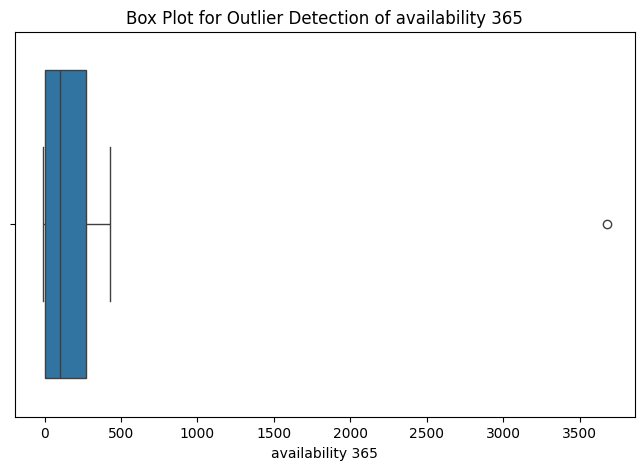

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

def check_outliers(df, column:str):
  plt.figure(figsize=(8,5))
  sns.boxplot(x=df[column])
  plt.title(f"Box Plot for Outlier Detection of {column}")
  plt.show()



for col in df.select_dtypes(include='number'):
  check_outliers(df,col)
  print("="*100)

So the column avialability 365 has one very odd outlier

In [60]:
df['availability 365'].max()

np.int64(3677)

In [61]:
df = df[df['availability 365'] < df['availability 365'].max()]

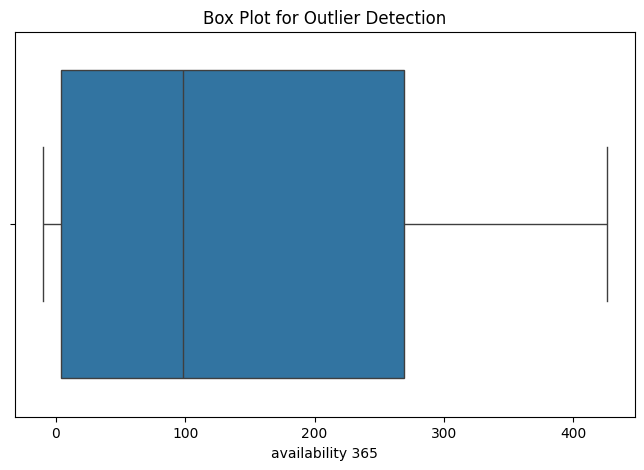

In [62]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['availability 365'])
plt.title(f"Box Plot for Outlier Detection")
plt.show()

In [63]:
df.describe()

,lat,long,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,96510.000000,96510.000000,96510.0,96510.000000,96510.000000,96510.0,96510.0,96510.000000,96510.000000,96510.0,96510.0
mean,40.728072,-73.949609,2012.488913,625.309294,125.062781,8.111325,27.378323,1.278651,3.283339,8.018029,141.719563
std,0.055837,0.049597,5.763484,331.795702,66.362660,28.973521,49.408772,1.628666,1.282898,32.447285,134.960366
min,40.499790,-74.249840,2003.0,50.000000,10.000000,-1223.0,0.0,0.010000,1.000000,1.0,-10.0
25%,40.688700,-73.982600,2008.0,339.000000,68.000000,2.0,1.0,0.280000,2.000000,1.0,4.0
50%,40.722320,-73.954480,2012.0,625.000000,125.000000,3.0,7.0,0.740000,3.000000,1.0,98.0
75%,40.762740,-73.932295,2017.0,913.000000,183.000000,5.0,30.0,1.710000,4.000000,2.0,269.0
max,40.916970,-73.705220,2022.0,1200.000000,240.000000,5645.0,1024.0,90.000000,5.000000,332.0,426.0


Still the availability 365, calculated host listings count, reviews per month, number of reviews , minimum nights and service fee have the outliers

In [64]:
# Define the columns to check for outliers
cols = [
    "availability 365",
    "calculated host listings count",
    "reviews per month",
    "number of reviews",
    "minimum nights",
    "service fee",
]

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for these columns
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

# Define the acceptable bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a filter/mask for rows that do NOT contain outliers in any of these columns
mask = ~((df[cols] < lower_bound) | (df[cols] > upper_bound)).any(axis=1)

# Apply the mask to the DataFrame
df = df[mask].reset_index(drop=True)

In [65]:
df.describe()

,lat,long,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,57935.000000,57935.000000,57935.0,57935.000000,57935.000000,57935.0,57935.0,57935.000000,57935.000000,57935.0,57935.0
mean,40.727592,-73.950255,2012.489411,625.220005,125.044049,2.797756,12.926348,0.865704,3.258117,1.292293,114.721567
std,0.056556,0.047360,5.777905,331.422791,66.287612,1.729365,17.08821,0.838574,1.294702,0.584673,131.043531
min,40.499790,-74.244420,2003.0,50.000000,10.000000,1.0,0.0,0.010000,1.000000,1.0,-10.0
25%,40.688420,-73.981280,2007.0,340.000000,68.000000,1.0,1.0,0.220000,2.000000,1.0,0.0
50%,40.720210,-73.954070,2012.0,625.000000,125.000000,2.0,5.0,0.740000,3.000000,1.0,59.0
75%,40.763205,-73.934285,2018.0,912.000000,182.000000,4.0,18.0,1.090000,4.000000,1.0,211.0
max,40.916970,-73.710870,2022.0,1200.000000,240.000000,9.0,73.0,3.850000,5.000000,3.0,426.0


## Save the Clean Data

In [67]:
df.to_csv('clean_aibanb_listing.csv', index=False)